# 2,7 millones de árboles. ¿Compiten o cooperan?

La respuesta depende de dónde estés parado en el planeta.

---

**Paper:** Detto, M. et al. *The importance of competition and facilitation for global tree diversity.* Nature (2026).
**DOI:** [10.1038/s41586-026-10349-2](https://doi.org/10.1038/s41586-026-10349-2)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-10-competencia-facilitacion-diversidad-arboles/notebook.ipynb)

**Video:** [Pendiente]

## El experimento más grande sobre vecinos arbóreos

Imagina censar 2,7 millones de árboles en 17 parcelas forestales, desde Yasuní (Ecuador, 0,7° de latitud) hasta Utah (37,7°). Más de 5.400 especies. El equipo de ForestGEO midió si cada especie tiene **más o menos vecinos de lo esperado por azar** — la señal de si los árboles se ayudan entre sí (facilitación) o se estorban (competencia).

La pregunta: ¿cambia esa relación con la latitud?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_TROPICAL = 15          # Latitud que separa ecuatorial de templado
RADIO_ANALISIS = 10           # Radio de vecindad en metros
FUENTE = 'Fuente: Detto et al. (2026), Nature | Datos: Supplementary Tables + ForestGEO GitHub'
COLOR_FACILITACION = '#059669'   # Emerald — cooperación
COLOR_COMPETENCIA = '#DC2626'    # Rojo — competencia
COLOR_TEMPERATURA = '#D97706'    # Amber — temperatura
COLOR_DIVERSIDAD = '#7C3AED'     # Violeta — diversidad
COLOR_REFERENCIA = '#2563EB'     # Azul CaM

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Descargar datos si no existen localmente
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-04-10-competencia-facilitacion-diversidad-arboles'
os.makedirs('datos', exist_ok=True)
for fname in ['proporciones_relativas.csv', 'proporciones_absolutas.csv', 'sitios_forestales.csv']:
    if not os.path.exists(f'datos/{fname}'):
        urllib.request.urlretrieve(f'{BASE}/datos/{fname}', f'datos/{fname}')

# Cargar
prop_rel = pd.read_csv('datos/proporciones_relativas.csv')
prop_abs = pd.read_csv('datos/proporciones_absolutas.csv')
sitios = pd.read_csv('datos/sitios_forestales.csv')

# Filtrar: radio de análisis, métrica de abundancia
grad = prop_rel[(prop_rel['radius_m'] == RADIO_ANALISIS) & (prop_rel['metric'] == 'abundance')].copy()
name_map = {
    'Barro Colorado Island (BCI)': 'BCI', 'Baishanzu': 'BSZ', 'Chebaling': 'CBL',
    'Dinghushan': 'DHS', 'Gutianshan': 'GTS', 'Heishiding': 'HSD',
    'Jianfengling': 'JFL', 'Luquillo': 'LUQ', 'Nanling': 'Nanling',
    'Palanan': 'Palanan', 'Pasoh': 'Pasoh', 'Puer': 'Puer', 'Rabi': 'Rabi',
    'Tai Po Kau': 'TPK', 'Utah': 'Utah', 'Wanang': 'Wanang', 'Yasuni': 'Yasuni'
}
grad['site_code'] = grad['plot'].map(name_map)
grad = grad.merge(sitios[['site', 'annu.temp', 'spe.rich', 'soil.temp', 'map']],
                  left_on='site_code', right_on='site', how='left')

print(f'✅ {len(grad)} parcelas cargadas')
print(f'   Latitud: {grad["latitude"].min():.1f}° – {grad["latitude"].max():.1f}°')
print(f'   Especies: {sitios["spe.rich"].sum():,} (sumando todas las parcelas)')
print(f'   Facilitación media: {grad["proportion"].mean():.1%}')

✅ 17 parcelas cargadas
   Latitud: 2.6° – 64.7°
   Especies: 5,567 (sumando todas las parcelas)
   Facilitación media: 35.6%


## Aquí está el gradiente.

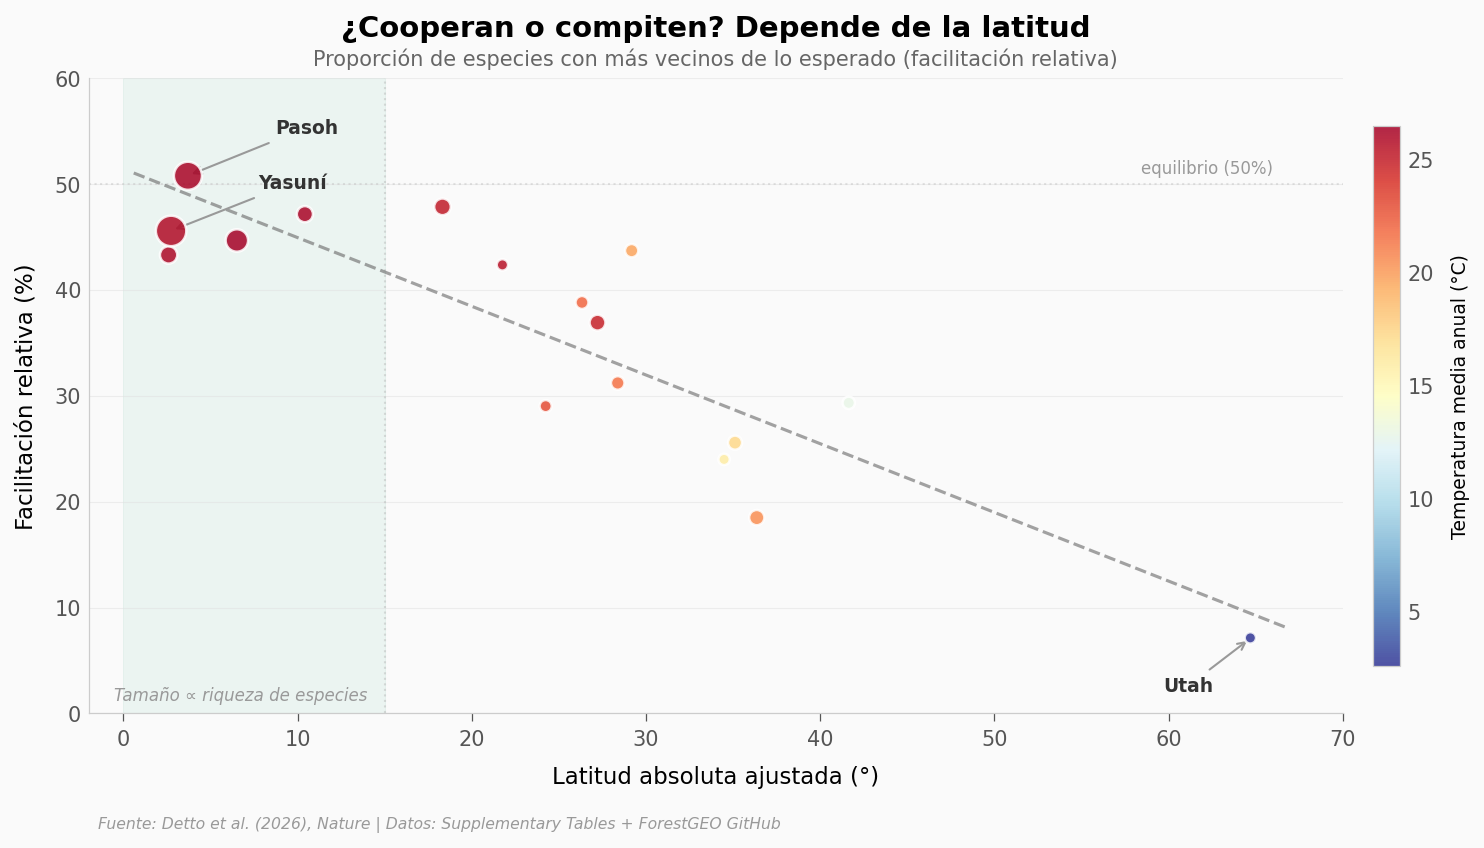

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Scatter: cada punto es una parcela
sizes = np.clip(grad['spe.rich'] / 5, 30, 300)
scatter = ax.scatter(grad['latitude'], grad['proportion'] * 100,
                     c=grad['annu.temp'], cmap='RdYlBu_r',
                     s=sizes, alpha=0.85, edgecolors='white', linewidths=1.2, zorder=5)

# Línea de tendencia (regresión lineal para visualización)
slope, intercept, r_val, p_val, se = stats.linregress(grad['latitude'], grad['proportion'] * 100)
x_fit = np.linspace(grad['latitude'].min() - 2, grad['latitude'].max() + 2, 100)
ax.plot(x_fit, slope * x_fit + intercept, color='#666666', linewidth=1.5,
        linestyle='--', alpha=0.6, zorder=3)

# Zona ecuatorial
ax.axvspan(0, UMBRAL_TROPICAL, color=COLOR_FACILITACION, alpha=0.06, zorder=1)
ax.axvline(x=UMBRAL_TROPICAL, color='#BBBBBB', linewidth=1, linestyle=':', alpha=0.5)

# Referencia 50%
ax.axhline(y=50, color='#BBBBBB', linewidth=1, linestyle=':', alpha=0.4)
ax.text(66, 51, 'equilibrio (50%)', fontsize=8, color='#999999', ha='right')

# Inline labels para extremos
extremos = [('Pasoh', 3.70, 50.8), ('Yasuní', 2.74, 45.6), ('Utah', 64.69, 7.1)]
for nombre, lat, prop in extremos:
    offset_y = 4 if nombre != 'Utah' else -5
    offset_x = 5 if nombre != 'Utah' else -5
    ha = 'left' if nombre != 'Utah' else 'right'
    ax.annotate(nombre, xy=(lat, prop), xytext=(lat + offset_x, prop + offset_y),
                fontsize=9, color='#333333', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#999999', lw=1))

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('Temperatura media anual (°C)', fontsize=9)

ax.set_title('¿Cooperan o compiten? Depende de la latitud',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Proporción de especies con más vecinos de lo esperado (facilitación relativa)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlabel('Latitud absoluta ajustada (°)', fontsize=11)
ax.set_ylabel('Facilitación relativa (%)', fontsize=11)
ax.set_xlim(-2, 70)
ax.set_ylim(0, 60)

# Nota tamaño
ax.text(0.02, 0.02, 'Tamaño ∝ riqueza de especies',
        transform=ax.transAxes, fontsize=8, color='#999999', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
os.makedirs('figuras', exist_ok=True)
plt.savefig('figuras/gradiente_facilitacion_latitud.png', dpi=200, bbox_inches='tight')
plt.show()

Cerca del ecuador, casi la mitad de las especies tiene más vecinos de lo esperado — las interacciones positivas y negativas están **en equilibrio aproximado** (media ecuatorial: 46,3%).

Pero a medida que nos alejamos del trópico, la facilitación se desploma. En las parcelas templadas, solo el 31,2% de las especies muestra ese patrón de vecindad positiva. La diferencia es de 15 puntos porcentuales (t-test: p = 0,013, Cohen's d = 1,50, n = 5 vs 12).

La correlación es fuerte: ρ = −0,82 (p < 0,001, n = 17). El color lo anticipa — las parcelas más cálidas (rojas) se agrupan arriba a la izquierda; las más frías (azules), abajo a la derecha.

Pasoh (Malasia, 3,7°) lidera con 50,8% de facilitación. Utah (37,7°), el extremo opuesto, apenas llega al 7,1% — una diferencia de 7× entre los extremos.

## ¿Quién domina: la cooperación o la competencia?

La facilitación es la historia bonita, pero la competencia domina en casi todas las parcelas. Veamos las proporciones absolutas en cada parcela.

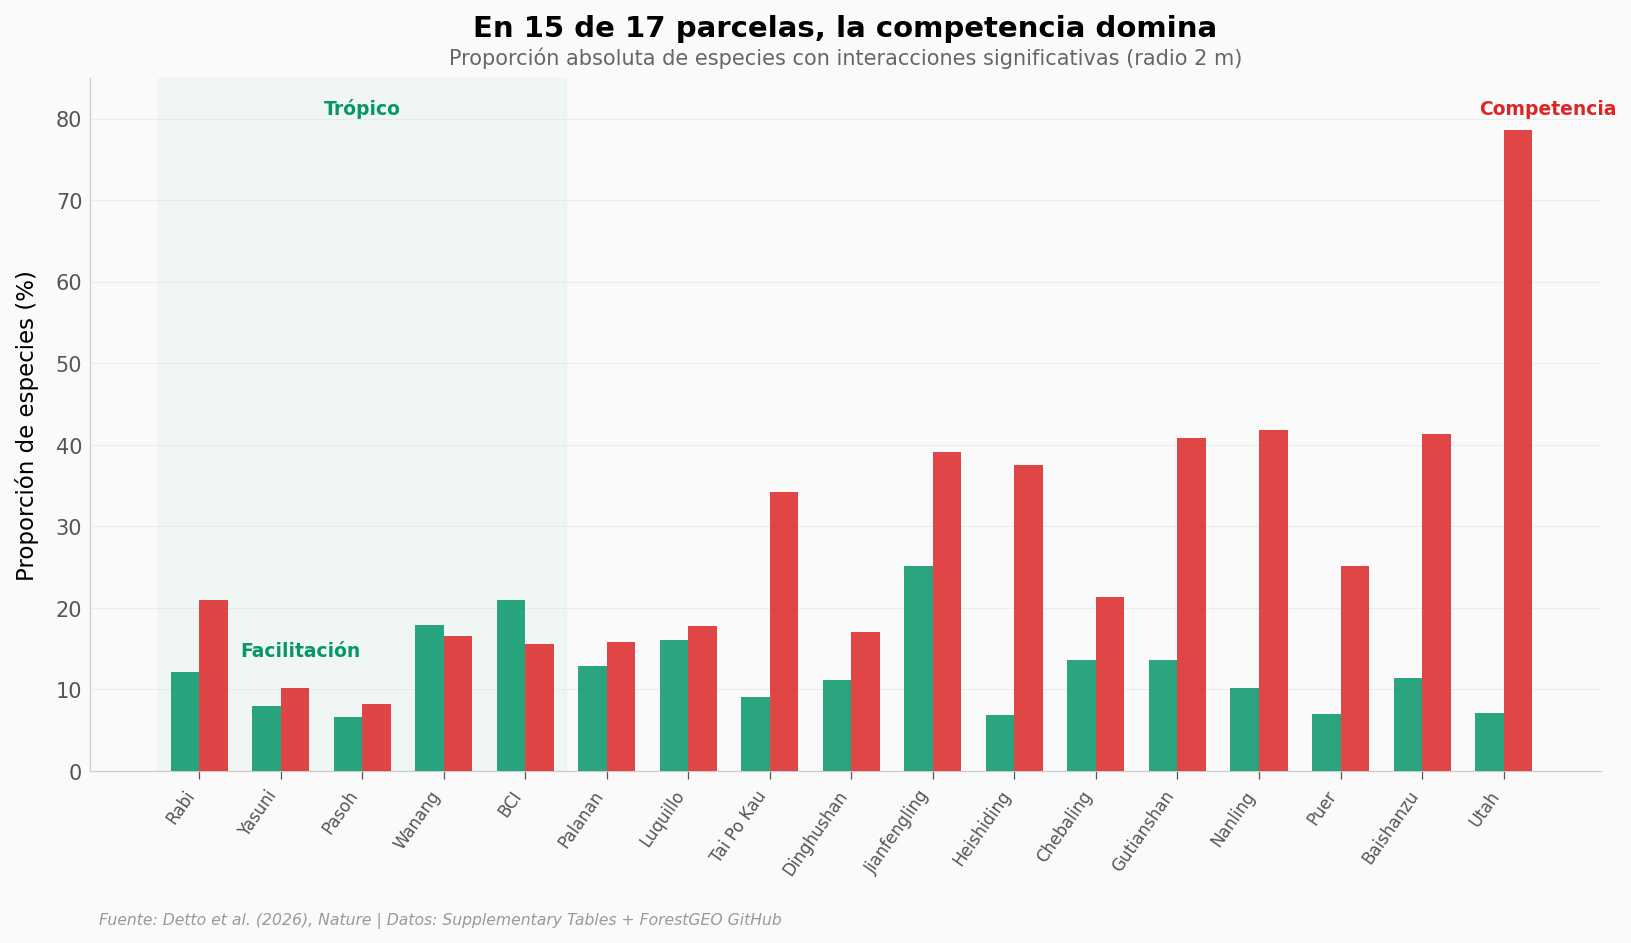

In [3]:
fig, ax = plt.subplots(figsize=(13, 6))

# Datos: proporciones absolutas a 2m, no estandarizadas, abundancia
abs_data = prop_abs[(prop_abs['radius_m'] == 2) &
                    (prop_abs['standardized'] == 'not standardized') &
                    (prop_abs['metric'] == 'abundance')].copy()

# Pivotar
pivot = abs_data.pivot(index='plot', columns='interaction', values='proportion')
pivot = pivot.merge(abs_data[['plot', 'latitude']].drop_duplicates(), on='plot')
pivot = pivot.sort_values('latitude')

x = np.arange(len(pivot))
width = 0.35

bars_pos = ax.bar(x - width/2, pivot['positive'] * 100, width,
                  color=COLOR_FACILITACION, alpha=0.85, label='Facilitación', zorder=5)
bars_neg = ax.bar(x + width/2, pivot['negative'] * 100, width,
                  color=COLOR_COMPETENCIA, alpha=0.85, label='Competencia', zorder=5)

# Etiquetas de parcela
plot_labels = [p.replace('Barro Colorado Island (BCI)', 'BCI') for p in pivot['plot']]
ax.set_xticks(x)
ax.set_xticklabels(plot_labels, rotation=55, ha='right', fontsize=8)

# Zona ecuatorial
n_ecuat = sum(pivot['latitude'] < UMBRAL_TROPICAL)
ax.axvspan(-0.5, n_ecuat - 0.5, color=COLOR_FACILITACION, alpha=0.04, zorder=1)
ax.text(n_ecuat / 2 - 0.5, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 80,
        'Trópico', fontsize=9, color=COLOR_FACILITACION, ha='center', fontweight='bold',
        va='top')

# Inline labels
ax.text(len(pivot) - 1.3, pivot.iloc[-1]['negative'] * 100 + 2, 'Competencia',
        fontsize=9, color=COLOR_COMPETENCIA, fontweight='bold')
ax.text(0.5, pivot.iloc[0]['positive'] * 100 + 2, 'Facilitación',
        fontsize=9, color=COLOR_FACILITACION, fontweight='bold')

ax.set_title('En 15 de 17 parcelas, la competencia domina',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Proporción absoluta de especies con interacciones significativas (radio 2 m)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylabel('Proporción de especies (%)', fontsize=11)
ax.set_ylim(0, 85)

fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/competencia_vs_facilitacion.png', dpi=200, bbox_inches='tight')
plt.show()

## La temperatura como mediadora

El paper dice que la temperatura media anual es la que conecta latitud con facilitación. ¿Lo vemos en los datos?

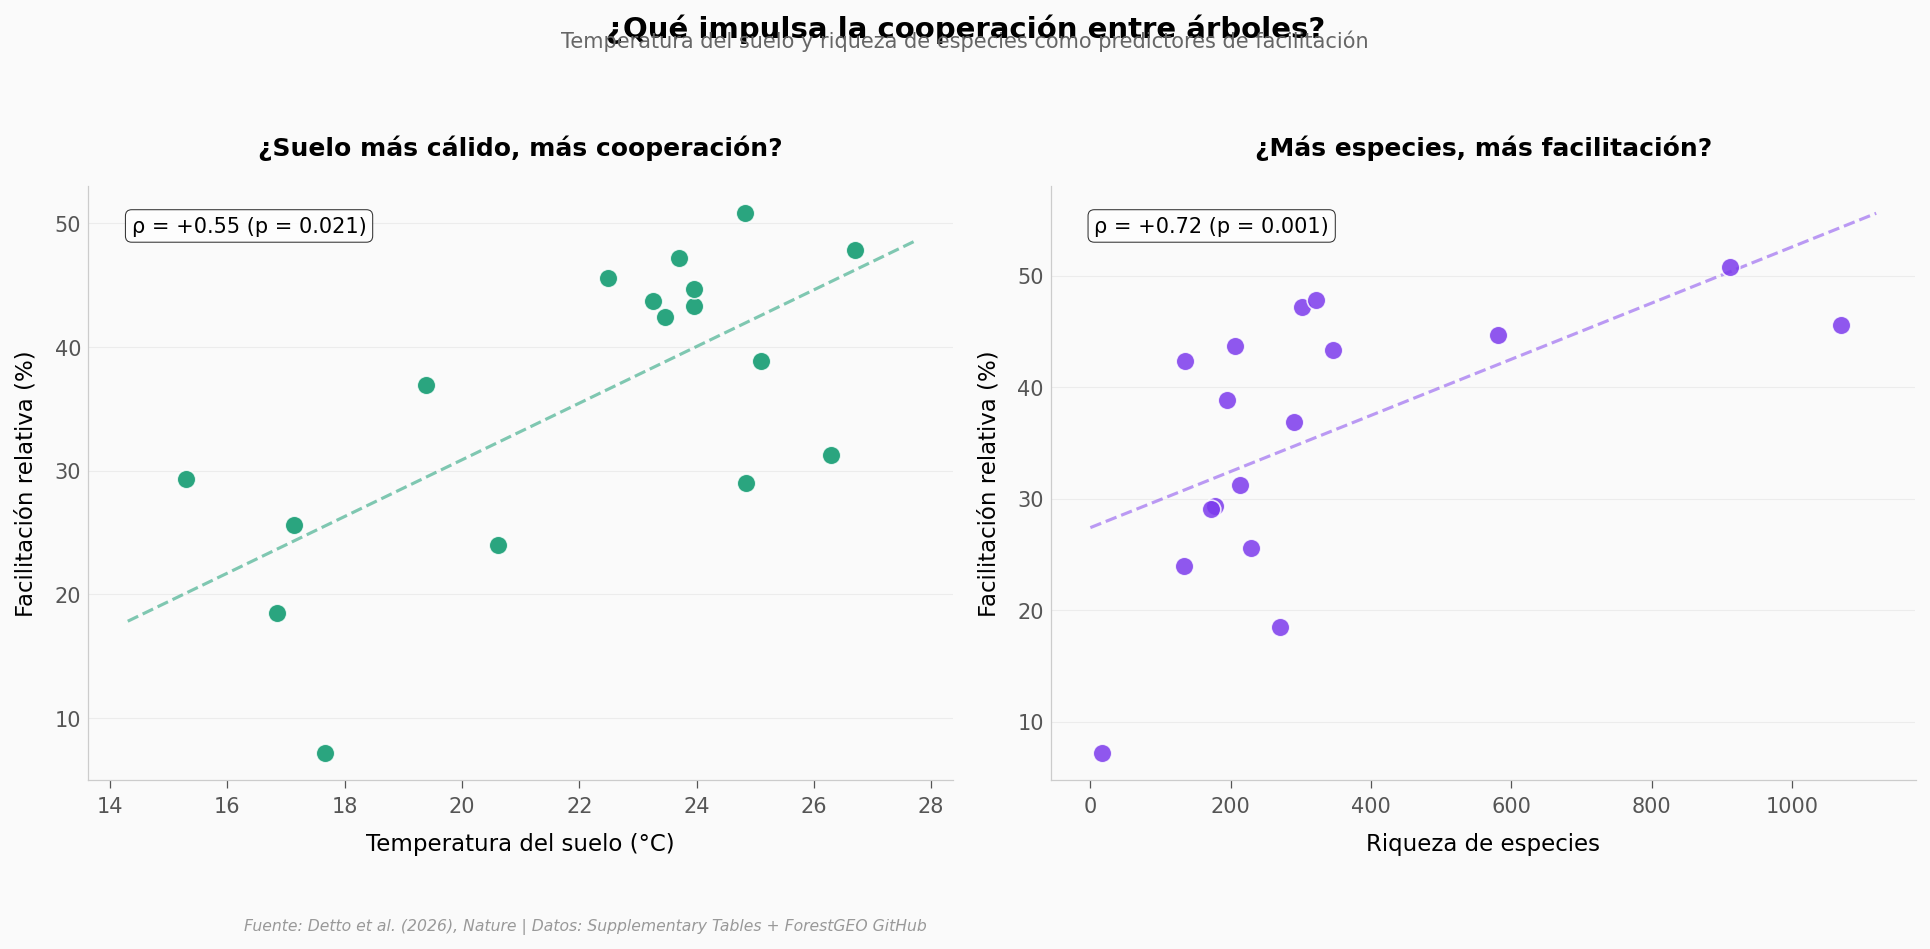

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel 1: Facilitación vs temperatura del suelo
valid = grad.dropna(subset=['soil.temp'])
ax1.scatter(valid['soil.temp'], valid['proportion'] * 100,
            c=COLOR_FACILITACION, s=80, alpha=0.85,
            edgecolors='white', linewidths=0.8, zorder=5)

# Tendencia
slope, intercept, r, p, se = stats.linregress(valid['soil.temp'], valid['proportion'] * 100)
x_fit = np.linspace(valid['soil.temp'].min() - 1, valid['soil.temp'].max() + 1, 100)
ax1.plot(x_fit, slope * x_fit + intercept, color=COLOR_FACILITACION,
         linewidth=1.5, linestyle='--', alpha=0.5)

rho_soil, p_soil = stats.spearmanr(valid['soil.temp'], valid['proportion'])
ax1.text(0.05, 0.95, f'ρ = {rho_soil:+.2f} (p = {p_soil:.3f})',
         transform=ax1.transAxes, fontsize=10, va='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax1.set_xlabel('Temperatura del suelo (°C)', fontsize=11)
ax1.set_ylabel('Facilitación relativa (%)', fontsize=11)
ax1.set_title('¿Suelo más cálido, más cooperación?',
              fontsize=12, fontweight='bold', pad=15)

# Panel 2: Riqueza de especies vs facilitación
ax2.scatter(grad['spe.rich'], grad['proportion'] * 100,
            c=COLOR_DIVERSIDAD, s=80, alpha=0.85,
            edgecolors='white', linewidths=0.8, zorder=5)

slope2, intercept2, r2, p2, se2 = stats.linregress(grad['spe.rich'], grad['proportion'] * 100)
x_fit2 = np.linspace(0, grad['spe.rich'].max() + 50, 100)
ax2.plot(x_fit2, slope2 * x_fit2 + intercept2, color=COLOR_DIVERSIDAD,
         linewidth=1.5, linestyle='--', alpha=0.5)

rho_rich, p_rich = stats.spearmanr(grad['spe.rich'], grad['proportion'])
ax2.text(0.05, 0.95, f'ρ = {rho_rich:+.2f} (p = {p_rich:.3f})',
         transform=ax2.transAxes, fontsize=10, va='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax2.set_xlabel('Riqueza de especies', fontsize=11)
ax2.set_ylabel('Facilitación relativa (%)', fontsize=11)
ax2.set_title('¿Más especies, más facilitación?',
              fontsize=12, fontweight='bold', pad=15)

fig.suptitle('¿Qué impulsa la cooperación entre árboles?',
             fontsize=14, fontweight='bold', y=1.05)
fig.text(0.5, 1.01, 'Temperatura del suelo y riqueza de especies como predictores de facilitación',
         fontsize=10, color='#666666', ha='center')

plt.tight_layout()
fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/drivers_facilitacion.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan marcado es este gradiente?

La temperatura media anual es el predictor más fuerte (ρ = +0,80, p < 0,001, n = 17), seguida de la riqueza de especies (ρ = +0,72, p = 0,001, n = 17). La temperatura del suelo muestra una asociación moderada (ρ = +0,55, p = 0,021, n = 17).

Veamos cómo se distribuye la facilitación entre las 17 parcelas.

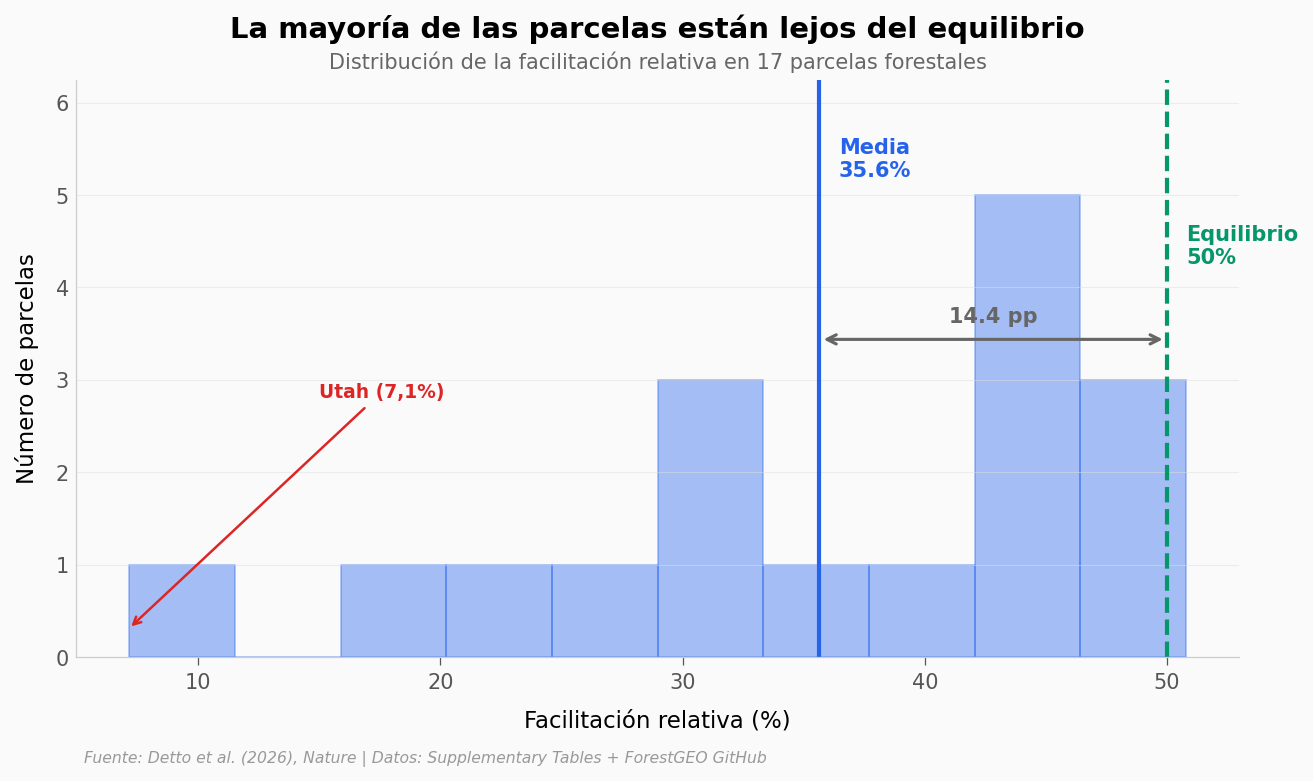

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

vals = grad['proportion'] * 100
n_bins, bins, patches = ax.hist(vals, bins=10, color=COLOR_REFERENCIA, alpha=0.4,
                                 edgecolor=COLOR_REFERENCIA, linewidth=0.8)

y_max = n_bins.max() * 1.25
ax.set_ylim(0, y_max)

# Media global
media = vals.mean()
ax.axvline(x=media, color=COLOR_REFERENCIA, linewidth=2, label=f'Media: {media:.1f}%')
ax.text(media + 0.8, y_max * 0.9, f'Media\n{media:.1f}%', fontsize=10,
        color=COLOR_REFERENCIA, fontweight='bold', va='top')

# Equilibrio (50%)
ax.axvline(x=50, color=COLOR_FACILITACION, linewidth=2, linestyle='--')
ax.text(50 + 0.8, y_max * 0.75, 'Equilibrio\n50%', fontsize=10,
        color=COLOR_FACILITACION, fontweight='bold', va='top')

# Flecha de diferencia
ax.annotate('', xy=(50, y_max * 0.55), xytext=(media, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff = 50 - media
ax.text((media + 50) / 2, y_max * 0.58, f'{diff:.1f} pp',
        fontsize=10, color='#666666', ha='center', fontweight='bold')

# Marcar Utah (extremo)
ax.annotate('Utah (7,1%)', xy=(7.1, 0.3), xytext=(15, y_max * 0.45),
            fontsize=9, color=COLOR_COMPETENCIA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_COMPETENCIA, lw=1.2))

ax.set_title('La mayoría de las parcelas están lejos del equilibrio',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Distribución de la facilitación relativa en 17 parcelas forestales',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Facilitación relativa (%)', fontsize=11)
ax.set_ylabel('Número de parcelas', fontsize=11)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_facilitacion.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Las interacciones negativas dominan en la mayoría de parcelas | ✅ | 15/17 parcelas (88%) con competencia > facilitación en proporciones absolutas |
| La facilitación relativa disminuye con la latitud | ✅ | ρ = −0,82 (p < 0,001). Cohen's d = 1,50 entre grupos ecuatorial/templado |
| Cerca del ecuador las proporciones son ~equilibradas | ✅ | Media ecuatorial = 46,3% (n = 5), cerca del 50% teórico |
| La temperatura del suelo se asocia con más facilitación | ✅ | ρ = +0,55 (p = 0,021, n = 17 parcelas) |
| El calentamiento global podría aumentar la facilitación en latitudes altas | ⚠️ | Los datos sugieren la asociación, pero el paper usa "suggest" y "could" — es una proyección, no un resultado directo |

> **Limitaciones:** (1) n = 17 parcelas — muestra pequeña para correlaciones ambientales, aunque las tres variables son significativas (p < 0,05). (2) Diseño observacional: las correlaciones con temperatura no implican causalidad. (3) Los datos fuente (árboles individuales) no están disponibles públicamente — trabajamos con las proporciones agregadas por parcela del Supplementary. (4) La variable "latitud ajustada" difiere de la latitud real en algunos sitios.

---

## Ahora tú

1. **¿Cambia la historia con otro radio?** Los datos incluyen radios de 2 a 16 m. ¿El gradiente se mantiene a 2 m (vecinos inmediatos) vs 16 m (vecindario amplio)? Pista: filtra `prop_rel[prop_rel['radius_m'] == 2]`.

2. **¿Qué pasa si usamos riqueza en vez de abundancia?** La métrica `richness` cuenta especies vecinas en vez de individuos. ¿El patrón es más fuerte o más débil?

3. **¿Hay un umbral de temperatura?** En vez de una correlación lineal, ¿existe un punto de temperatura donde la facilitación "despega"?

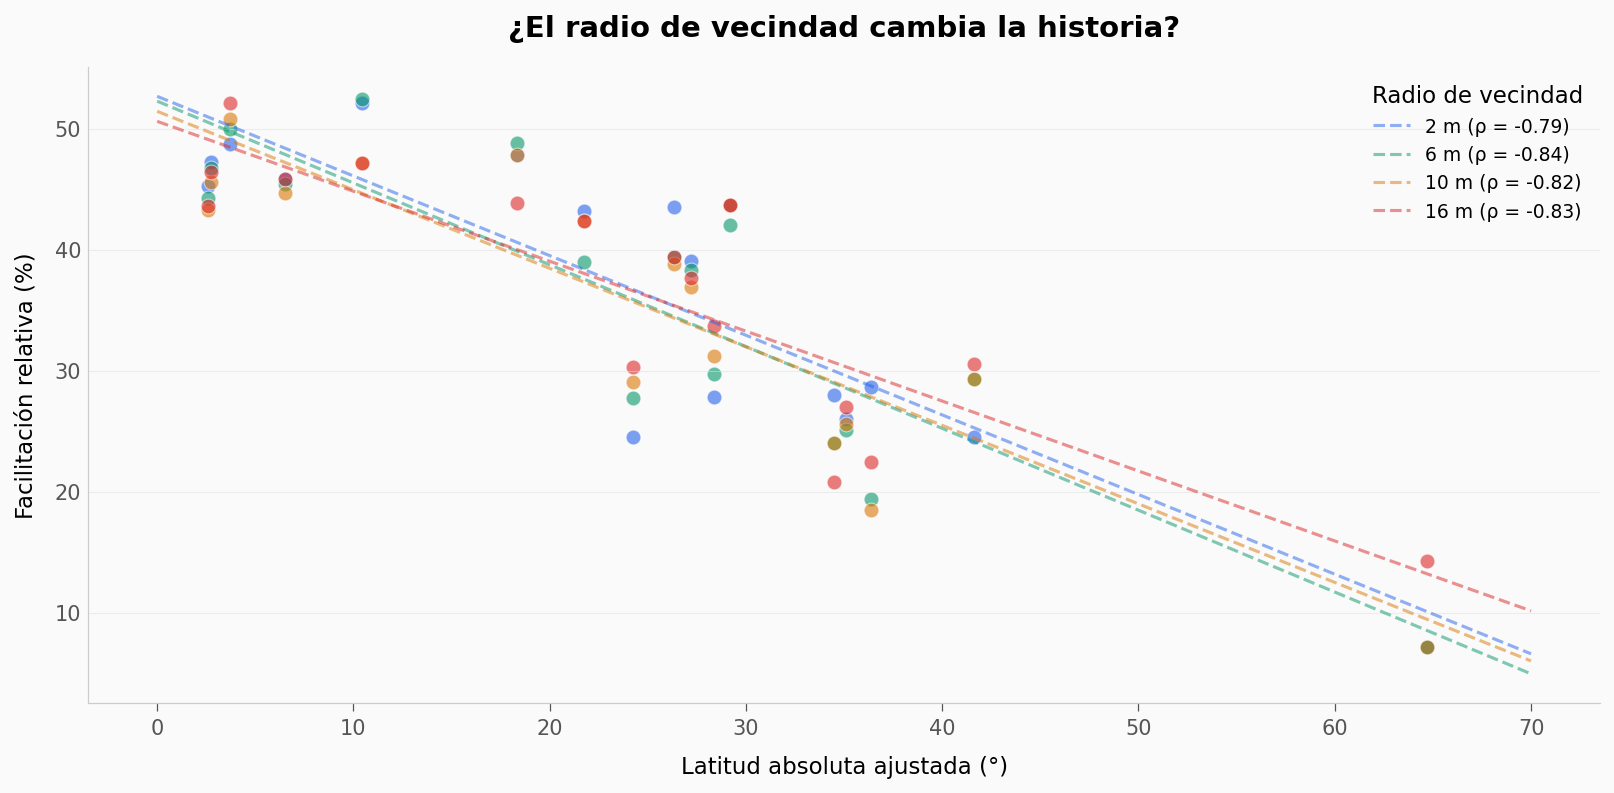

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Compara el gradiente a diferentes radios de vecindad

fig, ax = plt.subplots(figsize=(13, 5.5))

colores_radio = {2: '#2563EB', 6: '#059669', 10: '#D97706', 16: '#DC2626'}

for radio, color in colores_radio.items():
    sub = prop_rel[(prop_rel['radius_m'] == radio) & (prop_rel['metric'] == 'abundance')]
    rho, p = stats.spearmanr(sub['latitude'], sub['proportion'])
    ax.scatter(sub['latitude'], sub['proportion'] * 100,
               color=color, s=50, alpha=0.6, edgecolors='white', linewidths=0.5)
    # Tendencia
    slope, intercept, _, _, _ = stats.linregress(sub['latitude'], sub['proportion'] * 100)
    x_fit = np.linspace(0, 70, 100)
    ax.plot(x_fit, slope * x_fit + intercept, color=color, linewidth=1.5,
            linestyle='--', alpha=0.5, label=f'{radio} m (ρ = {rho:.2f})')

ax.legend(fontsize=9, loc='upper right', framealpha=0.9, title='Radio de vecindad')
ax.set_xlabel('Latitud absoluta ajustada (°)', fontsize=11)
ax.set_ylabel('Facilitación relativa (%)', fontsize=11)
ax.set_title('¿El radio de vecindad cambia la historia?',
             fontsize=14, fontweight='bold', pad=15)
plt.savefig('figuras/comparacion_radios.png', dpi=200, bbox_inches='tight')
plt.show()

---

### Créditos

- **Paper:** Detto, M. et al. (2026). *The importance of competition and facilitation for global tree diversity.* Nature. DOI: [10.1038/s41586-026-10349-2](https://doi.org/10.1038/s41586-026-10349-2)
- **Datos:** Supplementary Tables (MOESM3, MOESM4) + [ForestGEO GitHub](https://github.com/mdetto/Positive-Interactions)
- **Licencia datos:** Según ForestGEO Data Policy
- **Repo:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)